<a href="https://colab.research.google.com/github/naveen-pixel07/ML_2/blob/main/First_Order_Rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (30162, 15)

First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  


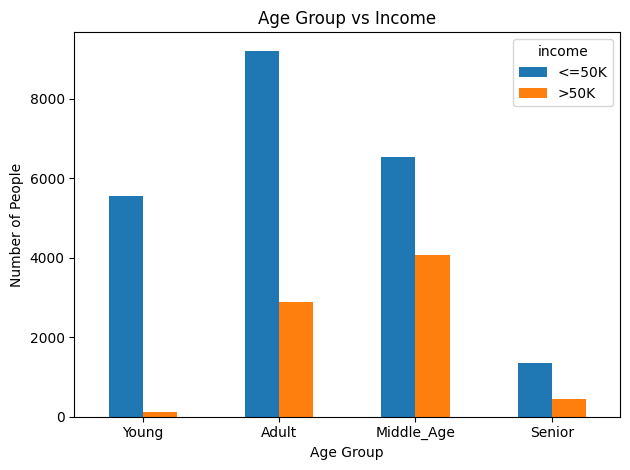

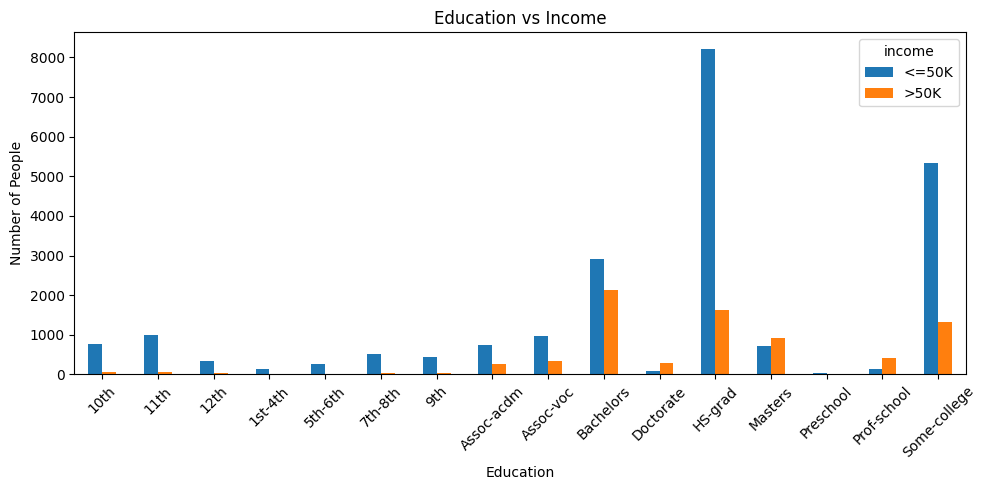

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD REAL UCI ADULT DATASET
# ==========================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education",
    "education_num", "marital_status", "occupation",
    "relationship", "race", "sex", "capital_gain",
    "capital_loss", "hours_per_week", "native_country",
    "income"
]

df = pd.read_csv(
    url,
    names=columns,
    skipinitialspace=True,
    na_values="?"
)

# Remove missing values
df.dropna(inplace=True)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


# ==========================================
# 2. CLASSIFICATION RULES
# ==========================================

print("\n========== CLASSIFICATION RULES ==========")

# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 40, 60, 100],
    labels=["Young", "Adult", "Middle_Age", "Senior"]
)

# Calculate majority class for each age group
rules = df.groupby("age_group", observed=True)["income"].agg(
    lambda x: x.mode()[0]
)

for group, result in rules.items():
    print(f"IF Age_Group = {group} THEN Income = {result}")


# ==========================================
# 3. FOIL-STYLE FIRST ORDER RULES
# ==========================================

print("\n========== FOIL FIRST-ORDER RULES ==========")

print("high_income(X) :- age_group(X, Middle_Age),")
print("                     education(X, Bachelors).")

print("high_income(X) :- age_group(X, Senior),")
print("                     hours_per_week(X, High).")

print("high_income(X) :- education(X, Masters),")
print("                     capital_gain(X, High).")


# ==========================================
# 4. FOIL-STYLE PREDICTION
# ==========================================

def foil_predict(age, education, hours):

    if age >= 40 and age <= 60 and education == "Bachelors":
        return ">50K"

    if age > 60 and hours >= 40:
        return ">50K"

    if education == "Masters" and hours >= 40:
        return ">50K"

    return "<=50K"


print("\n========== PREDICTIONS ==========")

test_people = [
    (45, "Bachelors", 40),
    (22, "HS-grad", 30),
    (65, "Bachelors", 45),
    (35, "Masters", 45)
]

for person in test_people:
    prediction = foil_predict(*person)

    print(
        f"Age={person[0]}, "
        f"Education={person[1]}, "
        f"Hours={person[2]} "
        f"--> Income={prediction}"
    )


# ==========================================
# 5. GRAPH 1 - AGE GROUP VS INCOME
# ==========================================

pd.crosstab(
    df["age_group"],
    df["income"]
).plot(kind="bar")

plt.title("Age Group vs Income")
plt.xlabel("Age Group")
plt.ylabel("Number of People")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ==========================================
# 6. GRAPH 2 - EDUCATION VS INCOME
# ==========================================

pd.crosstab(
    df["education"],
    df["income"]
).plot(kind="bar", figsize=(10, 5))

plt.title("Education vs Income")
plt.xlabel("Education")
plt.ylabel("Number of People")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()